In [ ]:
# Install required libraries
!pip install torchvision matplotlib scikit-learn

In [2]:
# Import PyTorch core library
import torch

# Import torchvision for datasets and transforms
import torchvision
import torchvision.transforms as transforms

# Import matplotlib for visualization
import matplotlib.pyplot as plt

In [3]:
# Define transformations for preprocessing images
# 1. Convert image to tensor
# 2. Normalize pixel values (-1 to 1 range)
transform = transforms.Compose([
    transforms.ToTensor(),                 # Convert image to tensor
    transforms.Normalize((0.5,), (0.5,))   # Normalize grayscale image
])

In [4]:
# Load training dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',          # Folder to store dataset
    train=True,             # Training dataset
    download=True,          # Download if not present
    transform=transform     # Apply transformations
)

# Load testing dataset
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,            # Test dataset
    download=True,
    transform=transform
)

100.0%
100.0%
100.0%
100.0%


In [5]:
# Create DataLoader for training data
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,          # Number of images per batch
    shuffle=True            # Shuffle data for better training
)

# Create DataLoader for testing data
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False           # No need to shuffle test data
)

In [6]:
# Get one batch of images and labels
images, labels = next(iter(train_loader))

# Print shape of images
print("Image shape:", images.shape)  
# Expected: [64, 1, 28, 28]

# Print first 10 labels
print("Labels:", labels[:10])

Image shape: torch.Size([64, 1, 28, 28])
Labels: tensor([3, 0, 8, 0, 5, 4, 2, 7, 3, 8])


In [7]:
import torch.nn as nn
import torch.nn.functional as F

# Define CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # First convolution layer
        self.conv1 = nn.Conv2d(
            in_channels=1,      # Input is grayscale image (1 channel)
            out_channels=32,    # Number of filters
            kernel_size=3,      # 3x3 filter
            padding=1           # Keep same size
        )

        # Second convolution layer
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Max pooling layer (reduces size)
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout layer (prevents overfitting)
        self.dropout = nn.Dropout(0.25)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # Flattened size
        self.fc2 = nn.Linear(128, 10)          # 10 classes

    def forward(self, x):
        # First conv block: Conv → ReLU → Pool
        x = self.pool(F.relu(self.conv1(x)))

        # Second conv block
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten the output
        x = x.view(-1, 64 * 7 * 7)

        # Apply dropout
        x = self.dropout(x)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [8]:
# Create model instance
model = SimpleCNN()

# Print model structure
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [9]:
# Loss function (for classification)
criterion = nn.CrossEntropyLoss()

# Optimizer (Adam)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [10]:
# Number of epochs 
epochs = 5

# Lists to store loss for plotting
train_losses = []

# Training loop
for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in train_loader:
        
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Add loss
        running_loss += loss.item()

    # Average loss for epoch
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.4528
Epoch 2, Loss: 0.2940
Epoch 3, Loss: 0.2511
Epoch 4, Loss: 0.2216
Epoch 5, Loss: 0.1981


In [11]:
# Set model to evaluation mode
model.eval()

correct = 0
total = 0

# Disable gradient calculation
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Print accuracy
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 91.29%


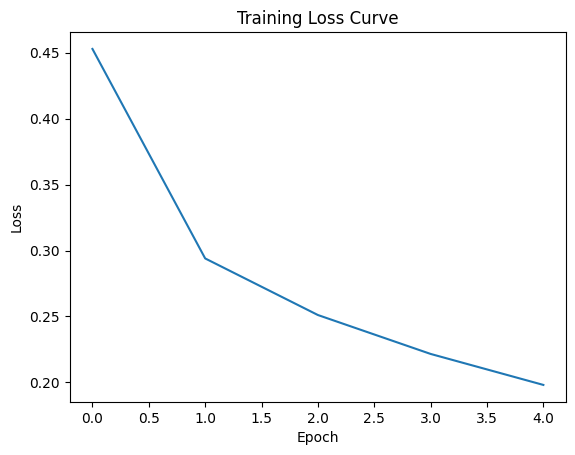

In [12]:
# Plot training loss curve
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

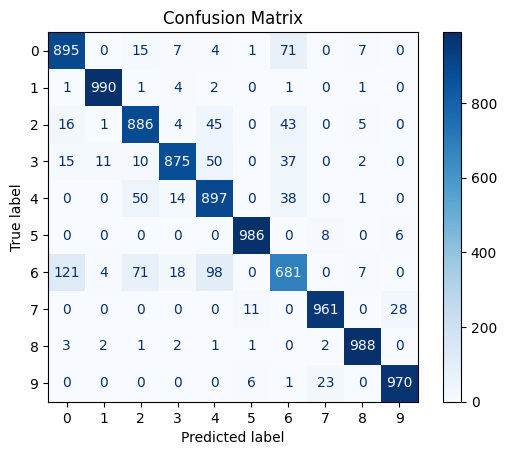

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Store predictions and true labels
all_preds = []
all_labels = []

# Disable gradient
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [19]:
#Define transform for ResNet
transform_resnet = transforms.Compose([
    transforms.Resize(224),                    # Resize image to 224x224
    transforms.Grayscale(num_output_channels=3),  # Convert to 3 channels
    transforms.ToTensor(),                    # Convert to tensor
    transforms.Normalize((0.5,), (0.5,))      # Normalize
])

In [20]:
#Load dataset again with new transform

train_dataset_resnet = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_resnet
)

test_dataset_resnet = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform_resnet
)

# Create DataLoaders
train_loader_resnet = torch.utils.data.DataLoader(
    train_dataset_resnet,
    batch_size=64,
    shuffle=True
)

test_loader_resnet = torch.utils.data.DataLoader(
    test_dataset_resnet,
    batch_size=64,
    shuffle=False
)

In [21]:
#Load ResNet18 model

import torchvision.models as models
import torch.nn as nn

resnet = models.resnet18(pretrained=True)

# Modify final layer for 10 classes
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

print(resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [22]:
#Loss function and optimizer

criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(resnet.parameters(), lr=0.001)

In [ ]:
resnet.eval()

images, labels = next(iter(test_loader_resnet))

outputs = resnet(images)

_, predicted = torch.max(outputs, 1)

print("Sample Predictions:", predicted[:10])
print("Actual Labels:", labels[:10])

In [1]:
import torchvision.models as models
import torch.nn as nn

# Load pretrained model
resnet = models.resnet18(pretrained=True)

# Modify last layer
resnet.fc = nn.Linear(resnet.fc.in_features, 10)

print("ResNet loaded successfully")

C:\Users\PANCHAMI KASHYAP\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\PANCHAMI KASHYAP\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet loaded successfully
